In [1]:
# Imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

pd.set_option("display.max_colwidth", 80)

In [2]:
# CELL 2 — Load HaluEval classification dataset
halueval_clf = pd.read_csv("../data/processed/halueval_classification.csv")
print("Full HaluEval shape:", halueval_clf.shape)
print("\nLabel distribution:")
print(halueval_clf["label"].value_counts())
halueval_clf.head(3)

Full HaluEval shape: (20000, 5)

Label distribution:
label
1    10000
0    10000
Name: count, dtype: int64


,question,answer,knowledge,label,answer_len
0,Which 2004 Nickelodeon show was created by Sue Rose and starred Molly Hagan?,no,"She co-starred in films ""Code of Silence"" (1985), ""Some Kind of Wonderful"" ...",1,1
1,Non-Stop starred the English actress best known for what role in Downton Abbey?,Michelle Dockery played Lady Mary.,Non-Stop is a 2014 American mystery action thriller film directed by Jaume C...,0,5
2,Cross country running is a sport in which teams and individuals run a race o...,mud or sand,"Sara McGreavy, born 13 December 1982 in Leamington Spa is an English and UK ...",0,3


In [3]:
# CELL 3 — Sample 5000 rows (2500 per class, stratified)
halueval_sample = (
    halueval_clf
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=2500, random_state=42))
    .reset_index(drop=True)
)

print("Sampled shape:", halueval_sample.shape)
print("\nLabel distribution after sampling:")
print(halueval_sample["label"].value_counts())
halueval_sample.head(3)

Sampled shape: (5000, 5)

Label distribution after sampling:
label
0    2500
1    2500
Name: count, dtype: int64


C:\Users\intel\AppData\Local\Temp\ipykernel_21020\1419979075.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=2500, random_state=42))


,question,answer,knowledge,label,answer_len
0,What brothers are known for How Six Made Their Way in the World and Grimms' ...,Jacob and Wilhelm,"""How Six Made Their Way in the World"" (German: ""Sechse kommen durch die ganz...",0,3
1,Who is a Bulgarian operatic soprano that had their career launched by The Wo...,Sonya Yoncheva,"Founded in 1993 by Plácido Domingo, the competition has helped launch the c...",0,2
2,What was the initial magnitude of the earthquake that formed Lake Isom?,The earthquake that formed Lake Isom had a magnitude of 7.5.,"Lake Isom is a small natural lake located in Lake County, Tennessee immediat...",0,11


In [4]:
# CELL 4 — Feature 1: Response length
halueval_sample["response_len"] = (
    halueval_sample["answer"].fillna("").str.split().str.len()
)
print("Response length stats:")
print(halueval_sample.groupby("label")["response_len"].describe())

Response length stats:
        count    mean      std  min  25%  50%   75%   max
label                                                    
0      2500.0  6.6896  6.39575  1.0  2.0  4.0  10.0  44.0
1      2500.0  1.0000  0.00000  1.0  1.0  1.0   1.0   1.0


In [5]:
# CELL 5 — Feature 2: Hedge count
HEDGE_WORDS = [
    "might", "may", "could", "possibly", "perhaps", "probably", "i think",
    "i believe", "i'm not sure", "unclear", "uncertain", "debated",
    "some say", "allegedly", "supposedly", "it seems", "appears to"
]

def count_hedges(text: str) -> int:
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(1 for h in HEDGE_WORDS if h in text_lower)

halueval_sample["hedge_count"] = halueval_sample["answer"].apply(count_hedges)
print("Hedge count stats:")
print(halueval_sample.groupby("label")["hedge_count"].describe())

Hedge count stats:
        count   mean       std  min  25%  50%  75%  max
label                                                  
0      2500.0  0.008  0.089102  0.0  0.0  0.0  0.0  1.0
1      2500.0  0.000  0.000000  0.0  0.0  0.0  0.0  0.0


In [6]:
print("Label 0 samples:")
print(halueval_sample[halueval_sample["label"]==0][["question","answer"]].head(3).to_string())

print("\nLabel 1 samples:")
print(halueval_sample[halueval_sample["label"]==1][["question","answer"]].head(3).to_string())

Label 0 samples:
                                                                                              question                                                        answer
0             What brothers are known for How Six Made Their Way in the World and Grimms' Fairy Tales?                                             Jacob and Wilhelm
1  Who is a Bulgarian operatic soprano that had their career launched by The World Opera Competition?                                                 Sonya Yoncheva
2                              What was the initial magnitude of the earthquake that formed Lake Isom?  The earthquake that formed Lake Isom had a magnitude of 7.5.

Label 1 samples:
                                                                                                                                                                                                                                                                                       question answer
2500      

In [11]:
halueval_clf = pd.read_csv("../data/processed/halueval_classification.csv")
print(halueval_clf.columns.tolist())
print("\nLabel 1 answer samples:")
print(halueval_clf[halueval_clf["label"]==1]["answer"].value_counts().head(10))
print("\nLabel 0 answer samples:")
print(halueval_clf[halueval_clf["label"]==0]["answer"].head(5).to_string())

['question', 'answer', 'knowledge', 'label', 'answer_len']

Label 1 answer samples:
answer
yes    5010
no     4990
Name: count, dtype: int64

Label 0 answer samples:
1                               Michelle Dockery played Lady Mary.
2                                                      mud or sand
3                                                           R2Bees
7     Jim Johnston's work with WWE (formerly WWF) started in 1985.
9    Gasland was released before The Truth According to Wikipedia.


In [8]:
from datasets import load_dataset
import pandas as pd

halueval_raw = pd.DataFrame(load_dataset("pminervini/HaluEval", "qa_samples", split="data"))
print(halueval_raw.columns.tolist())
print("\nShape:", halueval_raw.shape)
print("\nSample row:")
print(halueval_raw.head(2).to_string())
print("\nHallucinated answer samples:")
print(halueval_raw["hallucinated_answer"].head(5).to_string())

['knowledge', 'question', 'answer', 'hallucination']

Shape: (10000, 4)

Sample row:
                                                                                                                                                                                          knowledge                                                                           question                              answer hallucination
0  Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA.             Which magazine was started first Arthur's Magazine or First for Women?  First for Women was started first.           yes
1            The Oberoi family is an Indian family that is famous for its involvement in hotels, namely through The Oberoi Group.The Oberoi Group is a hotel company with its head office in Delhi.  The Oberoi family is part of a hotel company that has a head

KeyError: 'hallucinated_answer'

In [9]:
# Correct reshape — use hallucination column as label directly
halueval_correct = halueval_raw.copy()
halueval_correct["label"] = (halueval_correct["hallucination"] == "yes").astype(int)

print("Label distribution:")
print(halueval_correct["label"].value_counts())
print("\nLabel 0 (not hallucinated) samples:")
print(halueval_correct[halueval_correct["label"]==0][["question","answer"]].head(3).to_string())
print("\nLabel 1 (hallucinated) samples:")
print(halueval_correct[halueval_correct["label"]==1][["question","answer"]].head(3).to_string())

Label distribution:
label
1    5010
0    4990
Name: count, dtype: int64

Label 0 (not hallucinated) samples:
                                                                                                                          question                   answer
1                                                The Oberoi family is part of a hotel company that has a head office in what city?                    Delhi
2  Musician and satirist Allie Goertz wrote a song about the "The Simpsons" character Milhouse, who Matt Groening named after who?  President Richard Nixon
3                                                                                  What nationality was James Henry Miller's wife?                 American

Label 1 (hallucinated) samples:
                                                                           question                                     answer
0            Which magazine was started first Arthur's Magazine or First for Women?         First for Women

In [10]:
# Sample 5000 rows (2500 per class)
halueval_sample = (
    halueval_correct
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=2500, random_state=42))
    .reset_index(drop=True)
)

print("Sampled shape:", halueval_sample.shape)
print("Label distribution:")
print(halueval_sample["label"].value_counts())

Sampled shape: (5000, 5)
Label distribution:
label
0    2500
1    2500
Name: count, dtype: int64


C:\Users\intel\AppData\Local\Temp\ipykernel_21020\3922926499.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=2500, random_state=42))


In [12]:
# CELL 4 — Feature 1: Response length - updated and corercted
halueval_sample["response_len"] = (
    halueval_sample["answer"].fillna("").str.split().str.len()
)
print("Response length stats:")
print(halueval_sample.groupby("label")["response_len"].describe())

Response length stats:
        count     mean       std  min  25%  50%   75%   max
label                                                      
0      2500.0   2.2968  1.983301  1.0  1.0  2.0   3.0  32.0
1      2500.0  10.9928  6.364036  1.0  6.0  9.0  14.0  61.0


In [13]:
# CELL 5 — Feature 2: Hedge count - updated and corrected
HEDGE_WORDS = [
    "might", "may", "could", "possibly", "perhaps", "probably", "i think",
    "i believe", "i'm not sure", "unclear", "uncertain", "debated",
    "some say", "allegedly", "supposedly", "it seems", "appears to"
]

def count_hedges(text: str) -> int:
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(1 for h in HEDGE_WORDS if h in text_lower)

halueval_sample["hedge_count"] = halueval_sample["answer"].apply(count_hedges)
print("Hedge count stats:")
print(halueval_sample.groupby("label")["hedge_count"].describe())

Hedge count stats:
        count    mean       std  min  25%  50%  75%  max
label                                                   
0      2500.0  0.0064  0.079760  0.0  0.0  0.0  0.0  1.0
1      2500.0  0.0092  0.095493  0.0  0.0  0.0  0.0  1.0


In [14]:
# CELL 6 — Feature 3: ROUGE-1, ROUGE-L, BLEU
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

scorer   = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
smoother = SmoothingFunction().method1

def compute_rouge_bleu(response: str, reference: str) -> dict:
    if not isinstance(response, str) or not isinstance(reference, str):
        return {"rouge1": 0.0, "rougeL": 0.0, "bleu": 0.0}
    scores  = scorer.score(reference, response)
    ref_tok = reference.lower().split()
    hyp_tok = response.lower().split()
    bleu    = sentence_bleu([ref_tok], hyp_tok, smoothing_function=smoother)
    return {
        "rouge1": scores["rouge1"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure,
        "bleu"  : bleu
    }

print("Computing ROUGE/BLEU...")
rb = halueval_sample.progress_apply(
    lambda r: compute_rouge_bleu(r["answer"], r["knowledge"]), axis=1
)
halueval_sample["rouge1"] = rb.apply(lambda x: x["rouge1"])
halueval_sample["rougeL"] = rb.apply(lambda x: x["rougeL"])
halueval_sample["bleu"]   = rb.apply(lambda x: x["bleu"])
print("Done.")
print("\nROUGE-1 mean by label:")
print(halueval_sample.groupby("label")["rouge1"].mean())

Computing ROUGE/BLEU...


100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:13<00:00, 369.13it/s]

Done.

ROUGE-1 mean by label:
label
0    0.082693
1    0.232817
Name: rouge1, dtype: float64


In [15]:
# CELL 7 — Feature 4: Semantic similarity
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading sentence-transformers model...")
st_model = SentenceTransformer("all-MiniLM-L6-v2")

ref_embeddings = st_model.encode(
    halueval_sample["knowledge"].fillna("").tolist(),
    batch_size=64, show_progress_bar=True
)
ans_embeddings = st_model.encode(
    halueval_sample["answer"].fillna("").tolist(),
    batch_size=64, show_progress_bar=True
)
halueval_sample["sem_sim"] = cosine_similarity(
    ans_embeddings, ref_embeddings
).diagonal()

print("\nSemantic similarity mean by label:")
print(halueval_sample.groupby("label")["sem_sim"].mean())

# Autosave
os.makedirs("../data/processed", exist_ok=True)
halueval_sample.to_csv("../data/processed/halueval_features.csv", index=False)
print("saved after semantic similarity.")

Loading sentence-transformers model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]


Semantic similarity mean by label:
label
0    0.366116
1    0.557330
Name: sem_sim, dtype: float32
saved after semantic similarity.


In [17]:
print(halueval_raw[["question", "answer", "hallucination", "knowledge"]].head(5).to_string())

                                                                                                                          question                              answer hallucination                                                                                                                                                                                                                                                                                                                                                                                                                                                             knowledge
0                                                           Which magazine was started first Arthur's Magazine or First for Women?  First for Women was started first.           yes                                                                                                                                                                                         

In [19]:
# CELL 8 — Feature 5: BERTScore
from bert_score import score as bert_score

print("Computing BERTScore...")
cands = halueval_sample["answer"].fillna("").tolist()
refs  = halueval_sample["knowledge"].fillna("").tolist()

P, R, F1 = bert_score(
    cands, refs,
    lang="en",
    model_type="distilbert-base-uncased",
    batch_size=32,
    verbose=True
)
halueval_sample["bertscore_f1"] = F1.numpy()
print("\nBERTScore F1 mean by label:")
print(halueval_sample.groupby("label")["bertscore_f1"].mean())

halueval_sample.to_csv("../data/processed/halueval_features.csv", index=False)
print("saved after BERTScore.")

Computing BERTScore...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/301 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/157 [00:00<?, ?it/s]

done in 423.08 seconds, 11.82 sentences/sec

BERTScore F1 mean by label:
label
0    0.668469
1    0.752562
Name: bertscore_f1, dtype: float32
saved after BERTScore.


In [21]:
# CELL 9 — Feature 6: NLI entailment score
# Premise = knowledge passage, Hypothesis = answer
from transformers import pipeline

print("Loading NLI model...")
nli_pipe = pipeline(
    "text-classification",
    model="cross-encoder/nli-deberta-v3-small",
    device=-1
)

def get_nli_entailment(premise: str, hypothesis: str) -> float:
    if not isinstance(premise, str) or not isinstance(hypothesis, str):
        return 0.0
    try:
        result = nli_pipe(
            f"{premise[:400]} [SEP] {hypothesis[:400]}",
            truncation=True,
            max_length=512
        )
        label  = result[0]["label"].lower()
        score  = result[0]["score"]
        if label == "entailment":
            return score
        elif label == "contradiction":
            return -score
        else:
            return 0.0
    except Exception:
        return 0.0

print("Computing NLI scores...")
halueval_sample["nli_score"] = halueval_sample.progress_apply(
    lambda r: get_nli_entailment(r["knowledge"], r["answer"]), axis=1
)
print("\nNLI score mean by label:")
print(halueval_sample.groupby("label")["nli_score"].mean())

halueval_sample.to_csv("../data/processed/halueval_features.csv", index=False)
print("Autosaved after NLI.")

Loading NLI model...


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing NLI scores...


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [16:15<00:00,  5.12it/s]



NLI score mean by label:
label
0   -0.118916
1   -0.233434
Name: nli_score, dtype: float64
Autosaved after NLI.


In [23]:
#  CELL 10 — Verify & inspect feature matrix
feature_cols = [
    "response_len", "hedge_count", "rouge1", "rougeL",
    "bleu", "sem_sim", "bertscore_f1", "nli_score"
]

print(f"Shape: {halueval_sample.shape}")
print(f"\nNull counts:\n{halueval_sample[feature_cols].isnull().sum()}")
print(f"\nMean by label:")
print(halueval_sample.groupby("label")[feature_cols].mean().round(4))

Shape: (5000, 13)

Null counts:
response_len    0
hedge_count     0
rouge1          0
rougeL          0
bleu            0
sem_sim         0
bertscore_f1    0
nli_score       0
dtype: int64

Mean by label:
       response_len  hedge_count  rouge1  rougeL    bleu  sem_sim  \
label                                                               
0            2.2968       0.0064  0.0827  0.0827  0.0015   0.3661   
1           10.9928       0.0092  0.2328  0.1930  0.0188   0.5573   

       bertscore_f1  nli_score  
label                           
0            0.6685    -0.1189  
1            0.7526    -0.2334  


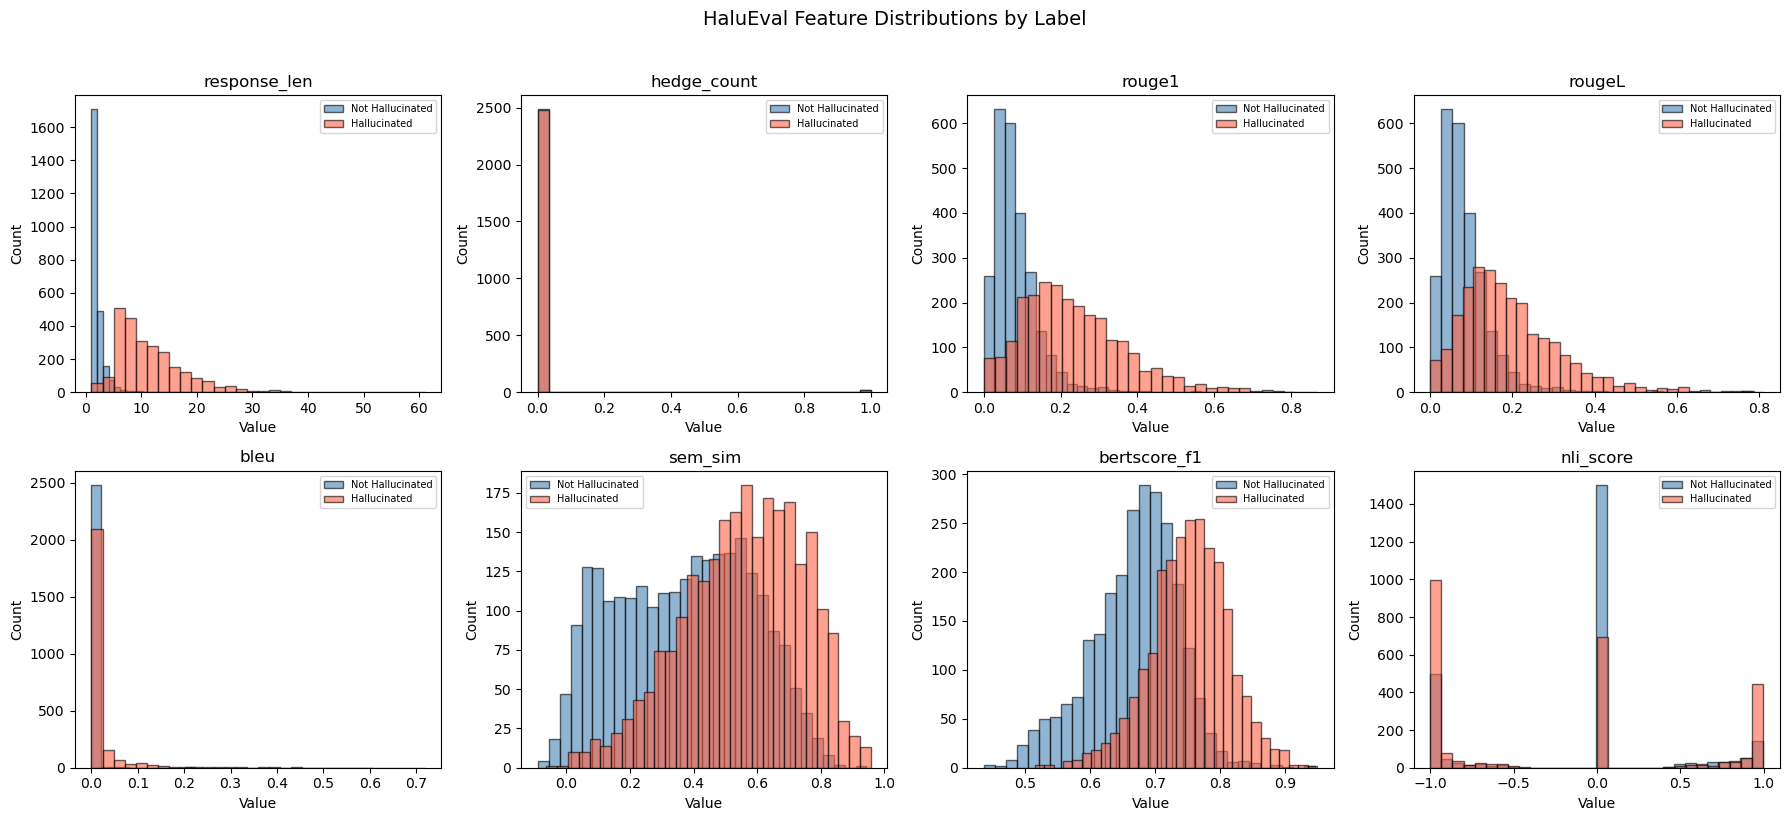

In [24]:
#  CELL 11 — EDA: Feature distributions by label
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    for label, grp in halueval_sample.groupby("label"):
        axes[i].hist(
            grp[feat], bins=30, alpha=0.6,
            label="Not Hallucinated" if label == 0 else "Hallucinated",
            color="steelblue" if label == 0 else "tomato",
            edgecolor="black"
        )
    axes[i].set_title(feat)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=7)

plt.suptitle("HaluEval Feature Distributions by Label", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/halueval_feature_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# CELL 12 — Save final feature matrix
halueval_sample.to_csv("../data/processed/halueval_features.csv", index=False)
print("Saved halueval_features.csv —", halueval_sample.shape)

Saved halueval_features.csv — (5000, 13)
